<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h1 style="color: var(--jp-content-font-color1, #1e6bb8); text-align: right; font-family: 'Vazirmatn', sans-serif;">یادگیری گروهی (ensemble learning): از یادگیرنده‌های ضعیف (weak learners) تا بگینگ (bagging) و بوستینگ (boosting)</h1>

<p style="text-align: right;">در این نوت‌بوک خواهیم‌آموخت:</p>

<ol style="text-align: right;">
<li style="text-align: right;">با <strong>یادگیرندهٔ ضعیف (weak learner)</strong> (درخت تصمیم (decision tree) کوچک) آشنا می‌شویم و بررسی می‌کنیم <em>چرا</em> ضعیف است.</li>
<li style="text-align: right;"><strong>تجزیهٔ بایاس–واریانس (bias-variance decomposition)</strong> خطای مورد انتظار (expected error) را می‌آموزیم و بایاس و واریانس یادگیرنده‌های ضعیف (weak learners) را به‌صورت تجربی <em>اندازه‌گیری</em> می‌کنیم.</li>
<li style="text-align: right;"><strong>بگینگ (bagging)</strong> (Bootstrap Aggregating) را می‌سازیم و بایاس و واریانس آن را اندازه می‌گیریم — سقوط واریانس را مشاهده خواهیم کرد.</li>
<li style="text-align: right;"><strong>جنگل تصادفی (random forest)</strong> — بگینگ (bagging) به‌علاوهٔ تصادفی‌سازی ویژگی ها (features) در هر انشعاب (split) — را می‌سازیم و کاهش <em>کرانهٔ واریانس (variance floor)</em> را خواهیم دید.</li>
<li style="text-align: right;"><strong>بوستینگ (boosting)</strong> (Gradient Boosting) را از ابتدا پیاده‌سازی می‌کنیم و سقوط بایاس را مشاهده می‌کنیم.</li>
<li style="text-align: right;">مقایسه: یادگیرندهٔ تک‌درخت در برابر بگینگ (bagging) در برابر جنگل تصادفی (random forest) در برابر بوستینگ (boosting).</li>
</ol>

<p style="text-align: right;"><strong>پیش‌نیاز:</strong> با درخت تصمیم (decision tree) آشنا هستید و احتمال مقدماتی (امید ریاضی، واریانس) را می‌دانید.</p>

<blockquote style="text-align: right; border-right: 4px solid #3498db; padding-right: 12px; margin-right: 0;">
<p style="text-align: right;"><strong>ایدهٔ کلیدی نوت‌بوک:</strong> خطای پیش‌بینی  مورد انتظار به سه بخش تجزیه می‌شود:</p>
<p style="text-align: right;">$\text{Error} = \text{Bias}^2 + \text{Variance} + \text{Irreducible noise}$</p>
<p style="text-align: right;">بگینگ (bagging) به جملهٔ <strong>واریانس</strong> حمله می‌کند؛ بوستینگ (boosting) به جملهٔ <strong>بایاس</strong>.</p>
</blockquote>

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="color: var(--jp-content-font-color1, #1e6bb8); text-align: right; font-family: 'Vazirmatn', sans-serif;">۰. آماده‌سازی</h2>

</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import BaggingRegressor, RandomForestClassifier, AdaBoostClassifier, GradientBoostingRegressor

plt.rcParams['figure.figsize'] = (9, 4.5)
plt.rcParams['figure.dpi'] = 110

RNG = np.random.default_rng(1001)   # one global rng for plots / single-dataset demos

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="color: var(--jp-content-font-color1, #1e6bb8); text-align: right; font-family: 'Vazirmatn', sans-serif;">۱. یادگیرندهٔ ضعیف (weak learner)</h2>

<p style="text-align: right;"><strong>یادگیرندهٔ ضعیف (weak learner)</strong> هر مدلی است که تنها اندکی بهتر از حدس تصادفی عمل کند. نمونهٔ کلاسیک آن <strong>استمپ تصمیم (decision stump)</strong> است: درخت تصمیم (decision tree)ی با عمق ۱، یعنی یک قانون سادهٔ «اگر $x \leq t$ آنگاه $a$، وگرنه $b$».</p>

<p style="text-align: right;">برای مطالعهٔ دقیق یادگیرنده‌های ضعیف (weak learners)، از یک <strong>مسئلهٔ رگرسیون (regression) یک‌بعدی که حقیقت آن را می‌دانیم</strong> استفاده می‌کنیم. تابع حقیقی عبارت است از:</p>

$$f(x) = \sin(4\pi x), \qquad x \in [0, 1]$$
<p style="text-align: right;">و هر مجموعه‌داده ای که رسم می‌کنیم شامل نمونه‌های نویزی است:</p>

$$y_i = f(x_i) + \varepsilon_i, \qquad \varepsilon_i \sim \mathcal{N}(0, \sigma^2), \quad \sigma = 0.3 .$$
<p style="text-align: right;">چون $f$ و $\sigma$ را می‌دانیم، می‌توانیم <strong>بایاس</strong> و <strong>واریانس</strong> را دقیقاً اندازه بگیریم. این امتیازی است که هرگز روی داده‌های واقعی نداریم — اما آزمایشگاهی ایده‌آل برای درک روش‌های گروه (ensemble)ی است.</p>

</div>

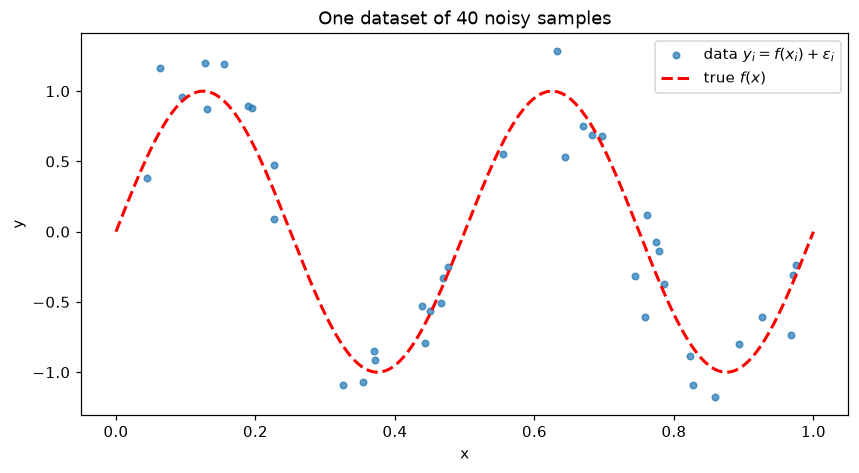

In [2]:
def f(x):
    """The true (unknown-to-the-model) function."""
    return np.sin(4 * np.pi * x)

SIGMA = 0.3                      # noise standard deviation
NOISE_VAR = SIGMA ** 2           # irreducible error = 0.09

x_grid = np.linspace(0, 1, 200).reshape(-1, 1)   # where we evaluate/plot predictions
f_grid = f(x_grid).ravel()                       # true values on the grid, 1-D

def make_dataset(n=40, rng=None):
    """Draw one training set: n random points with Gaussian noise."""
    rng = rng or RNG
    X = rng.uniform(0, 1, size=(n, 1))
    y = f(X.ravel()) + rng.normal(0, SIGMA, size=n)
    return X, y

# look at one dataset
X_demo, y_demo = make_dataset()
plt.scatter(X_demo, y_demo, s=18, alpha=0.7, label='data $y_i = f(x_i)+\\varepsilon_i$')
plt.plot(x_grid, f(x_grid), 'r--', lw=2, label='true $f(x)$')
plt.xlabel('x'); plt.ylabel('y'); plt.legend(); plt.title('One dataset of 40 noisy samples')
plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="color: var(--jp-content-font-color1, #1e6bb8); text-align: right; font-family: 'Vazirmatn', sans-serif;">۱.۱ یک استمپ چقدر ضعیف است؟</h3>

<p style="text-align: right;">بیایید یک استمپ تصمیم (decision stump) و درختانی با عمق کمی بیشتر را روی یک مجموعه‌داده  آموزش دهیم و ببینیم چه چیزی می‌توانند بیان کنند. یک استمپ تصمیم (decision stump) یک <strong>تابع پله‌ای (step function) با یک پله</strong> پیش‌بینی  می‌کند — و طبیعتاً نمی‌تواند یک موج سینوسی را دنبال کند.</p>

</div>

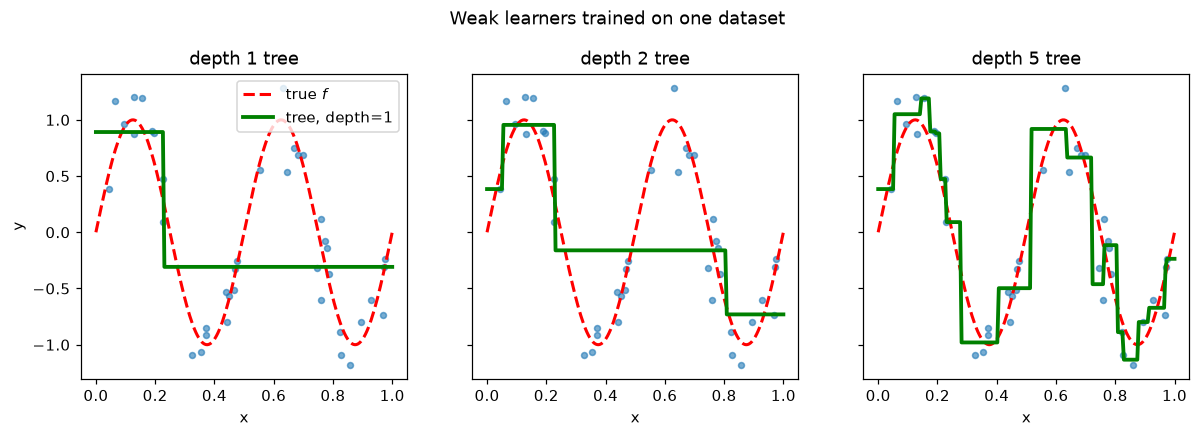

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, depth in zip(axes, [1, 2, 5]):
    tree = DecisionTreeRegressor(max_depth=depth).fit(X_demo, y_demo)
    ax.scatter(X_demo, y_demo, s=15, alpha=0.6)
    ax.plot(x_grid, f(x_grid), 'r--', lw=2, label='true $f$')
    ax.plot(x_grid, tree.predict(x_grid), 'g-', lw=2.5,
            label=f'tree, depth={depth}')
    ax.set_xlabel('x'); ax.set_title(f'depth {depth} tree')
axes[0].set_ylabel('y'); axes[0].legend()
plt.suptitle('Weak learners trained on one dataset', y=1.04)
plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<p style="text-align: right;">باید ببینید: <strong>استمپ تصمیم (decision stump) هر چقدر هم تلاش کند از حقیقت دور است</strong> (تنها ۲ سطح خروجی دارد)، در حالی که درخت عمیق‌تر نزدیک‌تر می‌شود اما شروع به واکنش نشان دادن به نویز می‌کند.</p>

<p style="text-align: right;">این موضوع به دو روش متفاوتی اشاره دارد که یک مدل می‌تواند <em>بد</em> باشد:</p>
<ul style="text-align: right;">
<li style="text-align: right;">می‌تواند <strong>خیلی خشک</strong> باشد → به‌طور سیستماتیک اشتباه → <strong>بایاس</strong> بالا؛</li>
<li style="text-align: right;">می‌تواند <strong>خیلی حساس</strong> به مجموعه‌داده  خاص باشد → پیش‌بینی ها (predictions) بین مجموعه‌داده ها جهش می‌کنند → <strong>واریانس</strong> بالا.</li>
</ul>

<p style="text-align: right;">بیایید این مفاهیم را دقیق کنیم.</p>

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="color: var(--jp-content-font-color1, #1e6bb8); text-align: right; font-family: 'Vazirmatn', sans-serif;">۲. تجزیهٔ بایاس–واریانس (bias-variance decomposition)</h2>

<p style="text-align: right;">یک مدل آموزش دیدهٔ $h_D$ به مجموعه‌داده  تصادفی $D$ که رسم کرده‌ایم بستگی دارد. پس $h_D(x)$ را به‌عنوان یک <strong>متغیر تصادفی</strong> در نظر بگیرید: تصادفی بودن از رسم مجموعه‌داده  آموزش  (و هر تصادفی بودن الگوریتمی) ناشی می‌شود.</p>

<p style="text-align: right;">برای تابع هزینهٔ مربعاتی، خطای مورد انتظار (expected error) در نقطهٔ $x$ <strong>دقیقاً</strong> تجزیه می‌شود:</p>

$$\underbrace{\mathbb{E}_{D,\,y}\left[(y - h_D(x))^2\right]}_{\text{expected error}} = \underbrace{\left(\bar{h}(x) - f(x)\right)^2}_{\text{Bias}^2} + \underbrace{\mathbb{E}_D\left[(h_D(x) - \bar{h}(x))^2\right]}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{noise}}$$
<p style="text-align: right;">که در آن $\bar{h}(x) = \mathbb{E}_D[h_D(x)]$ <strong>مدل میانگین (average model)</strong> است — مدل میانگین (average model)‌گیری‌شده روی تمام مجموعه‌داده های آموزشی ممکن.</p>

<p style="text-align: right;"><strong>خوانش جمله‌ها:</strong></p>
<ul style="text-align: right;">
<li style="text-align: right;"><strong>بایاس²</strong> — چقدر مدل <em>میانگین</em> اشتباه است. مدل‌های خشک (rigid models) (استمپ تصمیم ها (decision stumps)) بایاس بزرگی دارند. این خطای <em>سیستماتیک</em> است: هر مجموعه‌داده  تقریباً به همان پاسخ غلط منتهی می‌شود.</li>
<li style="text-align: right;"><strong>واریانس</strong> — چقدر یک مدل آموزش ‌دیدهٔ خاص حول میانگین نوسان می‌کند. مدل‌های انعطاف‌پذیر (flexible models) (درخت‌های عمیق (deep trees)) واریانس بزرگی دارند.</li>
<li style="text-align: right;"><strong>نویز $\sigma^2$</strong> — خطای خود برچسب‌ها. هیچ مدلی نمی‌تواند بر آن غلبه کند. این خطا <em>تحویل‌ناپذیر</em> است.</li>
</ul>

<h3 style="color: var(--jp-content-font-color1, #1e6bb8); text-align: right; font-family: 'Vazirmatn', sans-serif;">اندازه‌گیری با شبیه‌سازی</h3>

<p style="text-align: right;">نمی‌توانیم روی <em>همهٔ</em> مجموعه‌داده ها میانگین بگیریم، اما می‌توانیم امید ریاضی $\mathbb{E}_D$ را با رسم <strong>تعداد زیادی مجموعه‌داده </strong> تقریب بزنیم:</p>

<ol style="text-align: right;">
<li style="text-align: right;">برای $r = 1 \dots R$: مجموعه‌داده  $D_r$ را رسم کن، مدل $h_r$ را آموزش  بده، روی شبکهٔ ثابت پیش‌بینی کن → پیش‌بینی های $P_{r}(x)$.</li>
<li style="text-align: right;">میانگین پیش‌بینی  $\bar{P}(x) = \frac{1}{R}\sum_r P_r(x)$.</li>
<li style="text-align: right;">$\text{Bias}^2 \approx \frac{1}{n}\sum_x (\bar{P}(x) - f(x))^2$، واریانس $\approx \frac{1}{n}\sum_x \frac{1}{R}\sum_r (P_r(x) - \bar{P}(x))^2$.</li>
</ol>

</div>

In [4]:
def measure_bias_variance(fit_predict, n_trials=200):
    """
    fit_predict(trial) -> predictions of the trained model on x_grid (shape (200,)).
    Each call must draw its OWN random training set (seeded by `trial`).
    Returns (bias^2, variance, all predictions).
    """
    preds = np.array([fit_predict(t) for t in range(n_trials)])   # (R, n_grid)
    mean_pred = preds.mean(axis=0)
    bias2 = np.mean((mean_pred - f_grid) ** 2)                   # averaged over x
    variance = np.mean(preds.var(axis=0))                         # variance over D, averaged over x
    return bias2, variance, preds

def tree_fit_predict(depth, n_train=40):
    """Train a single tree of the given depth on a fresh dataset and predict on the grid."""
    def run(trial):
        rng = np.random.default_rng(trial)          # deterministic per trial -> reproducible
        X, y = make_dataset(n_train, rng=rng)
        tree = DecisionTreeRegressor(max_depth=depth).fit(X, y)
        return tree.predict(x_grid)
    return run

In [5]:
# Measure bias & variance for trees of increasing depth (the last one is fully grown = 'deep')
rows = []
for depth in [1, 2, 3, 6, 12]:
    b2, v, _ = measure_bias_variance(tree_fit_predict(depth))
    rows.append({'model': f'decision tree, depth={depth}',
                 'bias^2': b2, 'variance': v, '+ noise': NOISE_VAR,
                 'expected error': b2 + v + NOISE_VAR})
df = pd.DataFrame(rows).set_index('model').round(3)
df

,bias^2,variance,+ noise,expected error
model,,,,
"decision tree, depth=1",0.303,0.086,0.09,0.479
"decision tree, depth=2",0.162,0.164,0.09,0.416
"decision tree, depth=3",0.030,0.110,0.09,0.231
"decision tree, depth=6",0.003,0.106,0.09,0.199
"decision tree, depth=12",0.002,0.113,0.09,0.205


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<p style="text-align: right;"><strong>آنچه باید مشاهده کنید:</strong></p>
<ul style="text-align: right;">
<li style="text-align: right;">عمق ۱ (استمپ تصمیم (decision stump)): <strong>بایاس²</strong> بسیار بزرگ، واریانس کوچک — خیلی خشک.</li>
<li style="text-align: right;">عمق ۱۲: بایاس ناچیز، اما اکنون <strong>واریانس بر خطای کاهش‌پذیر غالب است</strong> — تقریباً تمام خطای باقی‌مانده نوسان است، یعنی نویز را برازش (fitting) می‌کند.</li>
<li style="text-align: right;">در میانه (عمق ۳–۶) <em>مجموع</em> کمینه است. این همان <strong>موازنهٔ بایاس–واریانس (bias-variance tradeoff)</strong> است.</li>
</ul>

<p style="text-align: right;">اکنون تصاویر پشت اعداد — ۴۰ استمپ تصمیم (decision stump) آموزش ‌دیده روی ۴۰ مجموعه‌داده  مختلف، و همین آزمایش برای درخت‌های عمیق (deep trees):</p>

</div>

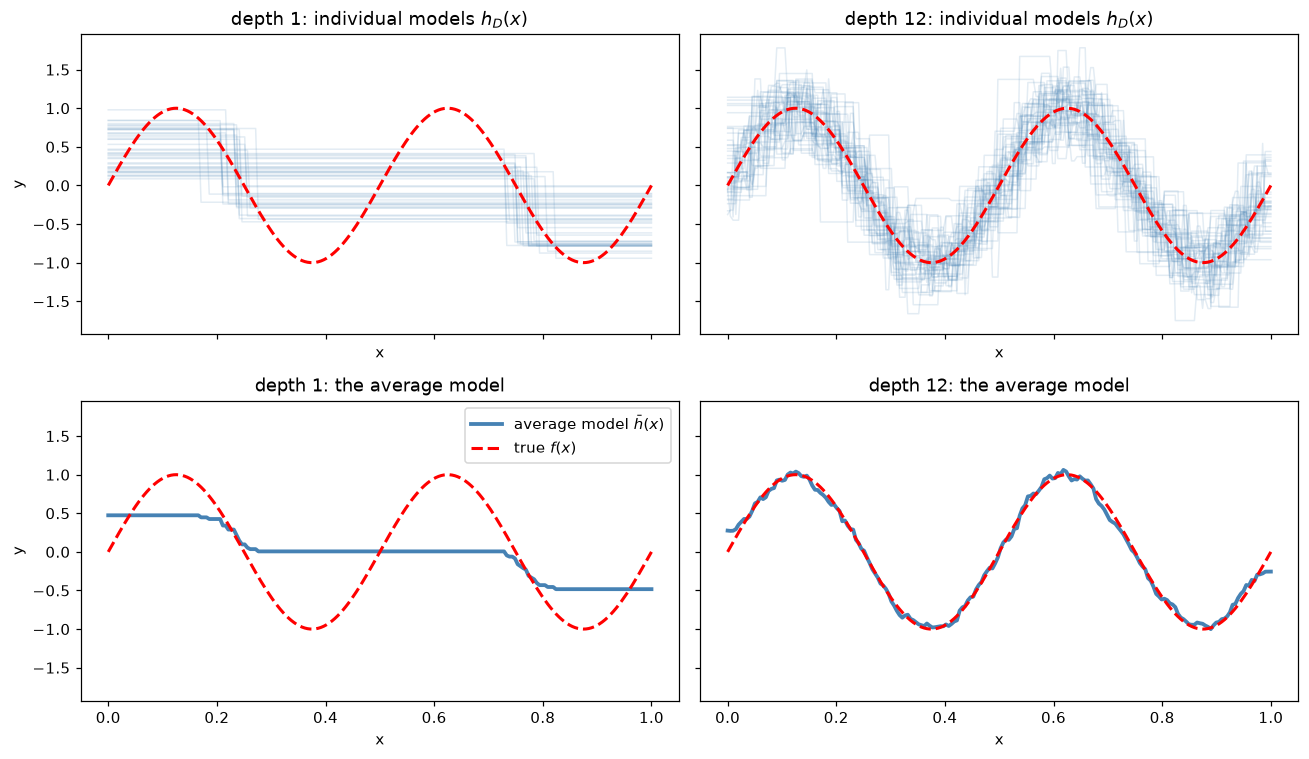

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
for col, depth in enumerate([1, 12]):
    _, _, preds = measure_bias_variance(tree_fit_predict(depth), n_trials=40)
    for r in range(preds.shape[0]):
        axes[0, col].plot(x_grid, preds[r], color='steelblue', alpha=0.15, lw=1)
    axes[1, col].plot(x_grid, preds.mean(axis=0), color='steelblue', lw=2.5, label='average model $\\bar{h}(x)$')
    for (ax, title) in [(axes[0, col], 'individual models $h_D(x)$'), (axes[1, col], 'the average model')]:
        ax.plot(x_grid, f(x_grid), 'r--', lw=2, label='true $f(x)$')
        ax.set_title(f'depth {depth}: {title}')
        ax.set_xlabel('x')
axes[0, 0].set_ylabel('y'); axes[1, 0].set_ylabel('y')
axes[1, 0].legend()
plt.tight_layout(); plt.show()

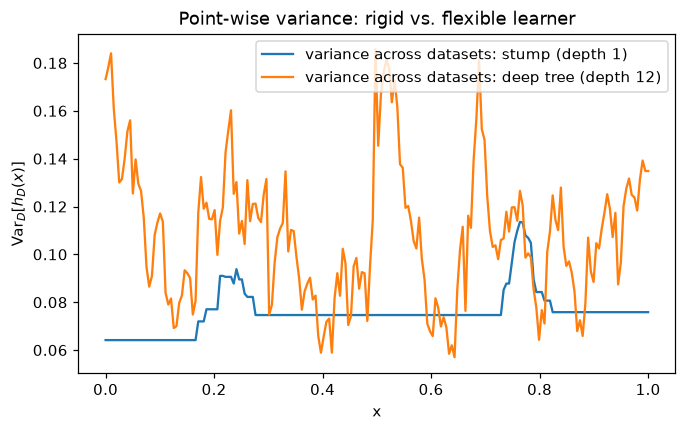

In [7]:
_, _, p_stump = measure_bias_variance(tree_fit_predict(1), n_trials=40)
_, _, p_deep  = measure_bias_variance(tree_fit_predict(12), n_trials=40)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_grid, p_stump.var(axis=0), label='variance across datasets: stump (depth 1)')
ax.plot(x_grid, p_deep.var(axis=0),  label='variance across datasets: deep tree (depth 12)')
ax.set_xlabel('x'); ax.set_ylabel('Var$_D[h_D(x)]$'); ax.legend()
plt.title('Point-wise variance: rigid vs. flexible learner')
plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="color: var(--jp-content-font-color1, #1e6bb8); text-align: right; font-family: 'Vazirmatn', sans-serif;">۳. بگینگ (bagging) و جنگل‌های تصادفی (random forests) — مبارزه با واریانس</h2>

<p style="text-align: right;"><strong>ایده:</strong> خطاهای یک مدل انعطاف‌پذیر (flexible model) (بایاس کم، واریانس زیاد) عمدتاً <em>تصادفی</em> هستند. اگر تعداد زیادی از این مدل‌ها را که روی مجموعه‌داده های (datasets) <em>مستقل</em> تصادفی آموزش  دیده‌اند میانگین بگیریم، نوسان تصادفی حذف می‌شود.</p>

<p style="text-align: right;"><strong>ریاضیات:</strong> اگر $h_1, \dots, h_B$ هم‌توزیع با واریانس $\sigma_h^2$ و همبستگی (correlation) جفتی $\rho$ باشند، آنگاه:</p>

$$\mathrm{Var}\!\left[\frac{1}{B}\sum_{b=1}^{B} h_b\right] = \sigma_h^2\left(\rho + \frac{1-\rho}{B}\right).$$
<p style="text-align: right;">دو نتیجه:</p>
<ol style="text-align: right;">
<li style="text-align: right;">وقتی $B \to \infty$، واریانس میانگین به صفر <strong>نمی‌رسد</strong> — در $\rho\,\sigma_h^2$ اشباع می‌شود (اعضا مستقل نیستند).</li>
<li style="text-align: right;">واریانس ابتدا مانند $1/B$ کاهش می‌یابد — دستاورد بزرگ با تعداد کمی مدل.</li>
</ol>

<p style="text-align: right;"><strong>ترفند بوت‌استرپ:</strong> در مسائل واقعی تنها <em>یک</em> مجموعه‌داده  $D$ داریم. بگینگ (bagging) با رسم <strong>نمونه‌های بوت‌استرپ (bootstrap samples)</strong> داشتن $B$ مجموعه‌داده  را شبیه‌سازی می‌کند: $n$ نقطه از $D$ <em>با جایگذاری</em> نمونه‌گیری می‌شود. هر نمونهٔ بوت‌استرپ (bootstrap sample) مجموعه‌داده  کمی متفاوت است، پس هر مدل کمی متفاوت خواهد بود.</p>

<p style="text-align: right;"><strong>بایاس چه می‌شود؟</strong> میانگین‌گیری یک مدل خشک (rigid model) را قوی تر نمی‌کند: میانگین استمپ تصمیم ها (decision stumps)ی زیاد همچنان تقریباً یک تابع تک‌پله‌ای است. <strong>بگینگ (bagging) واریانس را کاهش می‌دهد، نه بایاس را.</strong> (اثر هموارسازی مرتبهٔ دوم وجود دارد، اما پیام اصلی این است: واریانس ↓.)</p>

</div>

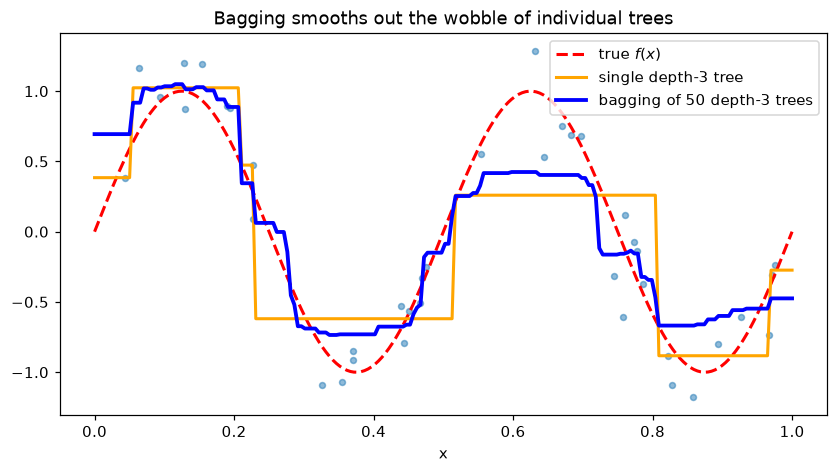

In [8]:
class SimpleBagging:
    """Bagging written from scratch: B trees on B bootstrap samples, average their predictions."""
    def __init__(self, B=50, base_depth=3):
        self.B = B
        self.base_depth = base_depth

    def fit(self, X, y, rng):
        """
        Train B base learners (decision tree regressors) on B bootstrap samples.

        Theory:
            Bagging (Bootstrap Aggregating) reduces variance by training multiple
            high-variance, low-bias learners on different bootstrap samples of the
            training data, then averaging their predictions.

            A bootstrap sample is created by drawing n indices uniformly WITH replacement
            from {0, 1, ..., n-1}, where n = len(y). Each sample contains ~63.2% of the
            original data points (some repeated). This simulates having B different
            training sets from the same distribution.

            The variance of the averaged ensemble is:
                Var[mean(h_1,...,h_B)] = sigma_h^2 * (rho + (1-rho)/B)
            which decreases as 1/B when B is small, and saturates at rho*sigma_h^2.

        Parameters:
            X : np.ndarray of shape (n_samples, n_features) - training features
            y : np.ndarray of shape (n_samples,) - training targets
            rng : np.random.Generator - random number generator for reproducibility

        Returns:
            self : the fitted SimpleBagging instance

        Side effects:
            Must set self.members = list of B fitted DecisionTreeRegressor objects.
        """
        # TODO: implement bagging fit
        raise NotImplementedError

    def predict(self, X, n_members=None):
        """
        Predict by averaging the predictions of the first n_members base learners.

        Theory:
            The ensemble prediction is the simple arithmetic mean of all member
            predictions: F(x) = (1/B) * sum_{b=1}^{B} h_b(x).
            This averaging is what reduces variance - uncorrelated errors cancel out.

        Parameters:
            X : np.ndarray of shape (n_samples, n_features) - features to predict on
            n_members : int or None - number of members to use (None = all members)

        Returns:
            np.ndarray of shape (n_samples,) - averaged predictions
        """
        # TODO: implement bagging predict
        raise NotImplementedError

# demo on one dataset
bag = SimpleBagging(B=50, base_depth=3).fit(X_demo, y_demo, np.random.default_rng(0))
single = DecisionTreeRegressor(max_depth=3).fit(X_demo, y_demo)

plt.scatter(X_demo, y_demo, s=15, alpha=0.5)
plt.plot(x_grid, f(x_grid), 'r--', lw=2, label='true $f(x)$')
plt.plot(x_grid, single.predict(x_grid), color='orange', lw=2, label='single depth-3 tree')
plt.plot(x_grid, bag.predict(x_grid), color='blue', lw=2.5, label='bagging of 50 depth-3 trees')
plt.xlabel('x'); plt.legend(); plt.title('Bagging smooths out the wobble of individual trees')
plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="color: var(--jp-content-font-color1, #1e6bb8); text-align: right; font-family: 'Vazirmatn', sans-serif;">۳.۱ اندازه‌گیری: بایاس و واریانس گروه بگینگ (bagging ensemble)</h3>

<p style="text-align: right;">اکنون آزمایش حیاتی. بایاس و واریانس را اندازه می‌گیریم برای:</p>
<ul style="text-align: right;">
<li style="text-align: right;">یک درخت <strong>تکی</strong> با عمق ۳ (یادگیرندهٔ نسبتاً ضعیف ما)، و</li>
<li style="text-align: right;">یک <strong>گروه بگینگ (bagging ensemble)</strong> با $B = 50$ درخت عمق ۳،</li>
</ul>

<p style="text-align: right;">به یاد داشته باشید که <em>کل گروه (ensemble)</em> مدل است، پس برای هر آزمایش مجموعه‌داده  را دوباره رسم می‌کنیم و کل گروه (ensemble) را بازآموزش (retraining)  می‌دهیم.</p>

<p style="text-align: right;">سلول زیر از یک ترفند استفاده می‌کند: برای هر مجموعه‌داده  $M$ عضو بوت‌استرپ را <strong>یک‌بار</strong> آموزش  می‌دهد و سپس گروه (ensemble) $B$-عضوی را به‌عنوان میانگین $B$ عضو اول می‌سازد. به این ترتیب هر مقدار $B$ را به دست می‌آوریم.</p>

</div>

In [9]:
M = 100                      # max number of bootstrap members per dataset
N_TRIALS = 200              # number of datasets (law of large numbers approximation of E_D)
BASE_DEPTH = 3

# member_preds[r, b, :] = prediction of bootstrap member b (trained on dataset r) on the grid
member_preds = np.zeros((N_TRIALS, M, len(x_grid)))
for r in range(N_TRIALS):
    rng = np.random.default_rng(r)
    X, y = make_dataset(40, rng=rng)
    for b in range(M):
        idx = rng.integers(0, len(y), size=len(y))
        member_preds[r, b] = DecisionTreeRegressor(max_depth=BASE_DEPTH)\
            .fit(X[idx], y[idx]).predict(x_grid)

def bagging_stats(B):
    """Bias/variance of the ensemble = mean of the first B bootstrap members, over all datasets."""
    preds = member_preds[:, :B, :].mean(axis=1)      # (R, n_grid): ensemble prediction per dataset
    mean_pred = preds.mean(axis=0)
    bias2 = np.mean((mean_pred - f_grid) ** 2)
    variance = np.mean(preds.var(axis=0))
    return bias2, variance

rows = []
b2_single, v_single, _ = measure_bias_variance(tree_fit_predict(BASE_DEPTH), n_trials=N_TRIALS)
rows.append({'model': f'single depth-{BASE_DEPTH} tree', 'B': 1,
             'bias^2': b2_single, 'variance': v_single, 'expected error': b2_single + v_single + NOISE_VAR})
for B in [5, 10, 25, 50, 100]:
    b2, v = bagging_stats(B)
    rows.append({'model': f'bagging, depth-{BASE_DEPTH} trees', 'B': B,
                 'bias^2': b2, 'variance': v, 'expected error': b2 + v + NOISE_VAR})
df_bag = pd.DataFrame(rows)
df_bag.round(3)

,model,B,bias^2,variance,expected error
0,single depth-3 tree,1,0.030,0.110,0.231
1,"bagging, depth-3 trees",5,0.034,0.066,0.190
2,"bagging, depth-3 trees",10,0.034,0.056,0.180
3,"bagging, depth-3 trees",25,0.034,0.049,0.174
4,"bagging, depth-3 trees",50,0.035,0.048,0.172
5,"bagging, depth-3 trees",100,0.035,0.047,0.172


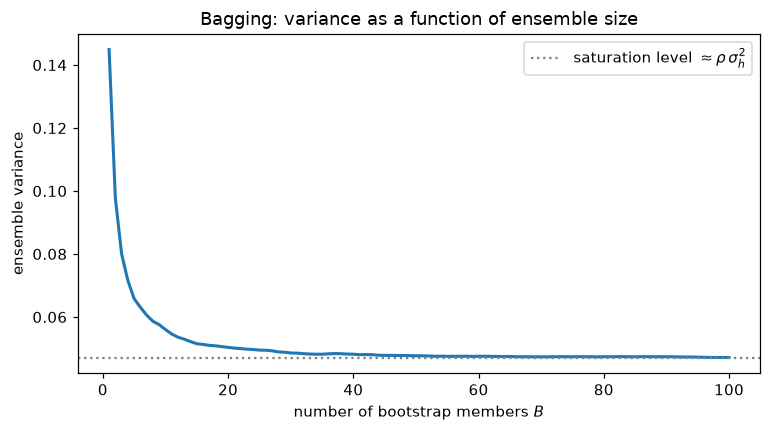

In [10]:
Bs = np.arange(1, M + 1)
var_curve = [bagging_stats(B)[1] for B in Bs]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(Bs, var_curve, lw=2)
ax.axhline(var_curve[-1], color='gray', ls=':', label='saturation level $\\approx \\rho\\,\\sigma_h^2$')
ax.set_xlabel('number of bootstrap members $B$'); ax.set_ylabel('ensemble variance')
ax.set_title('Bagging: variance as a function of ensemble size')
ax.legend(); plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<p style="text-align: right;"><strong>آنچه باید مشاهده کنید:</strong></p>
<ul style="text-align: right;">
<li style="text-align: right;"><strong>بایاس² تقریباً ثابت می‌ماند</strong> — همان مقدار درخت تکی..</li>
<li style="text-align: right;"><strong>واریانس به‌شدت کاهش می‌یابد</strong> — از ۰٫۱۱ به حدود ۰٫۰۵ در $B = 25$ تا ۵۰، سپس تخت می‌شود، دقیقاً مطابق پیش‌بینی  فرمول $\sigma_h^2(\rho + \frac{1-\rho}{B})$.</li>
</ul>

<p style="text-align: right;">این دقیقاً همان ترفند پشت <strong>جنگل تصادفی (random forest)</strong> است که اکنون می‌سازیم و اندازه می‌گیریم: تنوع بیشتر → همبستگی (correlation) کمتر $\rho$ → کرانهٔ واریانس (variance floor) پایین‌تر.</p>

<blockquote style="text-align: right; border-right: 4px solid #3498db; padding-right: 12px; margin-right: 0;">
<p style="text-align: right;"><strong>قاعدهٔ سرانگشتی:</strong> یک یادگیرندهٔ انعطاف‌پذیر با بایاس کم و واریانس زیاد را بگ کنید. بگینگ (bagging) یک استمپ تصمیم (decision stump) تقریباً کمکی نمی‌کند — مشکل آن بایاس است و بگینگ (bagging) نمی‌تواند بایاس را اصلاح کند.</p>
</blockquote>

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="color: var(--jp-content-font-color1, #1e6bb8); text-align: right; font-family: 'Vazirmatn', sans-serif;">۳.۲ جنگل تصادفی (random forest) — کاهش همبستگی (correlation) درخت‌ها</h3>

<p style="text-align: right;">بگینگ (bagging) یک کرانه دارد: حتی با بی‌نهایت درخت، واریانس گروه (ensemble) در $\rho\,\sigma_h^2$ اشباع می‌شود. چرا $\rho$ صفر نیست؟ زیرا نمونه‌های بوت‌استرپ (bootstrap samples) همپوشانی زیادی دارند (هر کدام حدود ۶۳٪ نقاط اصلی را حفظ می‌کنند)، بنابراین درخت‌ها عمدتاً داده‌های یکسانی می‌بینند، انشعاب (split)‌های یکسانی انتخاب می‌کنند و خطاهای یکسانی مرتکب می‌شوند.</p>

<p style="text-align: right;"><strong>جنگل تصادفی (random forest)</strong> یک مؤلفه به بگینگ (bagging) اضافه می‌کند: در <strong>هر انشعاب (split)</strong>، هر درخت تنها مجاز است یک <strong>زیرمجموعهٔ تصادفی (random subset) از $m$ ویژگی (feature)</strong> را در نظر بگیرد (معمولاً $m = \sqrt{p}$ برای دسته‌بندی (classification)، $m = p/3$ برای رگرسیون (regression)، که $p$ تعداد کل ویژگی ها (features)ست). درخت‌های مختلف اکنون روی متغیرهای متفاوتی انشعاب (split) می‌کنند، پس خطاهایشان <strong>غیرهمبسته (uncorrelated)</strong> می‌شود: $\rho$ کاهش می‌یابد و کرانهٔ واریانس (variance floor) $\rho\,\sigma_h^2$ نیز کاهش می‌یابد.</p>

<p style="text-align: right;">برای <em>دیدن</em> این اثر به بیش از یک ویژگی (feature) نیاز داریم، پس آزمایشگاهمان را ارتقا می‌دهیم: $x$ اکنون $D = 10$ مؤلفه دارد، تنها <strong>۳ مؤلفهٔ اول حامل سیگنال</strong> هستند:</p>

$$y = \sum_{j=1}^{3}\sin(4\pi x_j) + \varepsilon,$$
<p style="text-align: right;">و ۷ مؤلفهٔ دیگر نویز خالص‌اند. با ویژگی ها (features)ی زیاد، درخت‌های عمیق (deep trees)ی که <em>همه‌چیز</em> را می‌بینند مدام به دنبال ویژگی ها (features)ی نویزی می‌روند؛ جنگل تصادفی (random forest) درخت‌هایش را مجبور به تنوع می‌کند.</p>

</div>

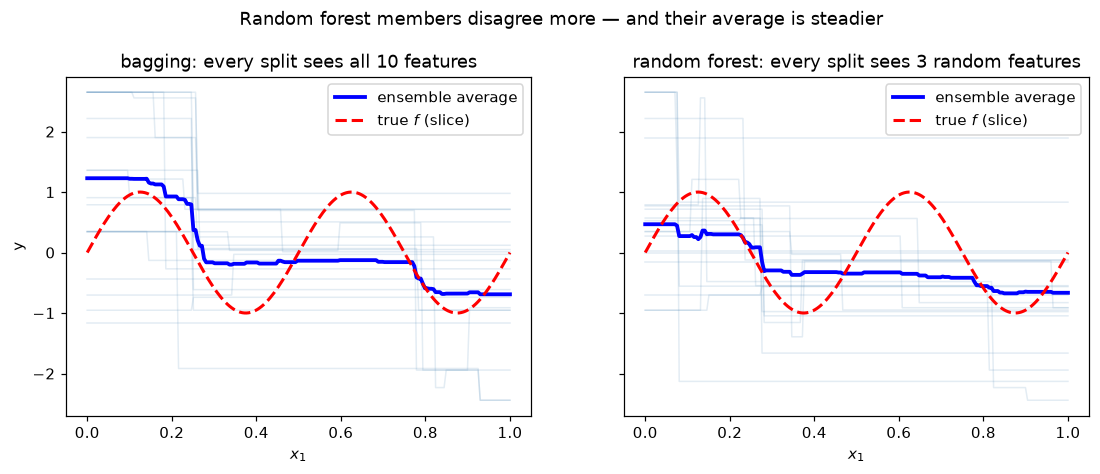

In [11]:
D = 10                                   # 10 features: x1..x3 carry the signal, x4..x10 are pure noise
N_INFO = 3
RF_DEPTH = 8
MAX_FEATURES = 3                         # features each split is allowed to look at

def f_multi(X):
    """True function of the multi-feature lab: depends on the first N_INFO coordinates only."""
    return sum(np.sin(4 * np.pi * X[:, j]) for j in range(N_INFO))

def make_dataset_multi(n=80, rng=None):
    X = rng.uniform(0, 1, size=(n, D))
    y = f_multi(X) + rng.normal(0, SIGMA, size=n)
    return X, y

# evaluation grid: vary x1, hold the other 9 features fixed at 0.5
x_grid_multi = np.full((len(x_grid), D), 0.5)
x_grid_multi[:, 0] = x_grid.ravel()
f_grid_multi = f_multi(x_grid_multi)

class SimpleRandomForest:
    """Random forest from scratch = SimpleBagging + a random feature subset at each split."""
    def __init__(self, B=50, base_depth=8, max_features=3):
        self.B = B
        self.base_depth = base_depth
        self.max_features = max_features

    def fit(self, X, y, rng):
        """
        Train B decision tree regressors, each on a bootstrap sample AND with
        a random feature subset constraint at every split.

        Theory:
            Random Forest = Bagging + feature randomness.
            Like bagging, it draws B bootstrap samples and trains one tree per sample.
            The KEY difference: at each split of each tree, only a random subset of
            `max_features` features are considered for splitting. This forces trees to
            be diverse (they split on different features), which reduces the pairwise
            correlation rho between tree predictions.

            Since ensemble variance = sigma_h^2 * (rho + (1-rho)/B), lowering rho
            directly lowers the variance floor. The tradeoff: each individual tree
            is slightly weaker (higher bias) because it can't always use the best feature.

        Parameters:
            X : np.ndarray of shape (n_samples, n_features) - training features
            y : np.ndarray of shape (n_samples,) - training targets
            rng : np.random.Generator - random number generator for reproducibility

        Returns:
            self : the fitted SimpleRandomForest instance

        Side effects:
            Must set self.members = list of B fitted DecisionTreeRegressor objects,
            each trained with max_features=self.max_features.
        """
        # TODO: implement random forest fit
        raise NotImplementedError

    def predict(self, X):
        """
        Predict by averaging the predictions of all trees in the forest.

        Parameters:
            X : np.ndarray of shape (n_samples, n_features) - features to predict on

        Returns:
            np.ndarray of shape (n_samples,) - averaged predictions
        """
        # TODO: implement random forest predict
        raise NotImplementedError

# demo on one dataset: bagging vs random forest, same base trees
rng_demo = np.random.default_rng(1)
X_multi, y_multi = make_dataset_multi(rng=rng_demo)

bag_multi = SimpleBagging(B=50, base_depth=RF_DEPTH).fit(X_multi, y_multi, np.random.default_rng(2))
rf_multi  = SimpleRandomForest(B=50, base_depth=RF_DEPTH, max_features=MAX_FEATURES)\
    .fit(X_multi, y_multi, np.random.default_rng(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, ens, name in [(axes[0], bag_multi, 'bagging: every split sees all 10 features'),
                      (axes[1], rf_multi, f'random forest: every split sees {MAX_FEATURES} random features')]:
    for t in ens.members[:20]:
        ax.plot(x_grid, t.predict(x_grid_multi), color='steelblue', alpha=0.15, lw=1)
    ax.plot(x_grid, ens.predict(x_grid_multi), color='blue', lw=2.5, label='ensemble average')
    ax.plot(x_grid, f_grid_multi, 'r--', lw=2, label='true $f$ (slice)')
    ax.set_title(name); ax.set_xlabel('$x_1$'); ax.legend()
axes[0].set_ylabel('y')
plt.suptitle('Random forest members disagree more — and their average is steadier', y=1.03)
plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="color: var(--jp-content-font-color1, #1e6bb8); text-align: right; font-family: 'Vazirmatn', sans-serif;">۳.۳ اندازه‌گیری: کرانهٔ واریانس (variance floor) بگینگ (bagging) در برابر جنگل تصادفی (random forest)</h3>

<p style="text-align: right;">همان آزمایش بخش ۳٫۱، روی آزمایشگاه ۱۰-ویژگی (feature): مجموعه‌داده های (datasets) زیادی رسم کنید و برای هر کدام یک درخت عمیق تکی، یک گروه (ensemble) بگینگ (bagging) (bagging ensemble) و یک جنگل تصادفی (random forest) آموزش  دهید. همچنین مستقیماً تخمین می‌زنیم:</p>
<ul style="text-align: right;">
<li style="text-align: right;">$\sigma_h^2$ — واریانس <strong>یک</strong> عضو (میانگین‌گیری‌شده روی اعضا و نقاط)، و</li>
<li style="text-align: right;">$\rho$ — <strong>میانگین همبستگی (correlation) جفتی</strong> بین پیش‌بینی ‌ها (predictions)ی اعضا.</li>
</ul>

<p style="text-align: right;">فرمول بخش ۳ پیش‌بینی  می‌کند که واریانس گروه (ensemble) باید به سمت $\rho\,\sigma_h^2$ با افزایش $B$ میل کند. بیایید بررسی کنیم آیا این‌طور هست — و آیا $\rho$ کوچک‌تر جنگل تصادفی (random forest) کرانهٔ پایین‌تری به آن می‌دهد.</p>

</div>

In [12]:
N_TRIALS_RF = 100                      # datasets
M_RF = 50                              # bootstrap members per dataset

bag_preds_m = np.zeros((N_TRIALS_RF, M_RF, len(x_grid)))
rf_preds_m  = np.zeros((N_TRIALS_RF, M_RF, len(x_grid)))
single_preds_m = np.zeros((N_TRIALS_RF, len(x_grid)))

for r in range(N_TRIALS_RF):
    rng = np.random.default_rng(1000 + r)
    X, y = make_dataset_multi(rng=rng)
    single_preds_m[r] = DecisionTreeRegressor(max_depth=RF_DEPTH).fit(X, y).predict(x_grid_multi)
    for b in range(M_RF):
        idx = rng.integers(0, len(y), size=len(y))
        bag_preds_m[r, b] = DecisionTreeRegressor(max_depth=RF_DEPTH).fit(X[idx], y[idx]).predict(x_grid_multi)
        rf_preds_m[r, b]  = DecisionTreeRegressor(max_depth=RF_DEPTH, max_features=MAX_FEATURES)\
            .fit(X[idx], y[idx]).predict(x_grid_multi)

def ensemble_stats_m(preds_3d, B):
    """Bias^2 and variance of the ensemble = average of the first B members."""
    preds = preds_3d[:, :B, :].mean(axis=1)
    return (np.mean((preds.mean(axis=0) - f_grid_multi) ** 2),
            np.mean(preds.var(axis=0)))

def member_correlation(preds_3d):
    """Average pairwise correlation between members' predictions (the rho of the formula)."""
    Mm = preds_3d.shape[1]
    rhos = [np.corrcoef(preds_3d[:, b, :].ravel(), preds_3d[:, b2, :].ravel())[0, 1]
            for b in range(0, Mm - 1, 5) for b2 in range(b + 1, min(b + 4, Mm))]
    return np.mean(rhos)

b2_single_m, v_single_m = ensemble_stats_m(single_preds_m[:, None, :], 1)
b2_bag_m,  v_bag_m  = ensemble_stats_m(bag_preds_m, M_RF)
b2_rf_m,   v_rf_m   = ensemble_stats_m(rf_preds_m,  M_RF)
rho_bag = member_correlation(bag_preds_m)
rho_rf  = member_correlation(rf_preds_m)
sigma2_bag = bag_preds_m.var(axis=1).mean()       # variance of ONE member, averaged over members and x
sigma2_rf  = rf_preds_m.var(axis=1).mean()

df_rf = pd.DataFrame([
    {'model': f'single depth-{RF_DEPTH} tree', 'bias^2': b2_single_m, 'variance': v_single_m,
     'member corr rho': 1.0, 'floor rho*sigma_h^2': v_single_m},
    {'model': f'bagging, {M_RF} trees (all {D} features)', 'bias^2': b2_bag_m, 'variance': v_bag_m,
     'member corr rho': rho_bag, 'floor rho*sigma_h^2': rho_bag * sigma2_bag},
    {'model': f'random forest, {M_RF} trees (max_features={MAX_FEATURES})',
     'bias^2': b2_rf_m, 'variance': v_rf_m,
     'member corr rho': rho_rf, 'floor rho*sigma_h^2': rho_rf * sigma2_rf},
]).set_index('model')
df_rf['expected error'] = df_rf['bias^2'] + df_rf['variance'] + NOISE_VAR
df_rf.round(3)

,bias^2,variance,member corr rho,floor rho*sigma_h^2,expected error
model,,,,,
single depth-8 tree,0.207,0.944,1.000,0.944,1.241
"bagging, 50 trees (all 10 features)",0.264,0.138,0.181,0.159,0.493
"random forest, 50 trees (max_features=3)",0.299,0.110,0.141,0.127,0.499


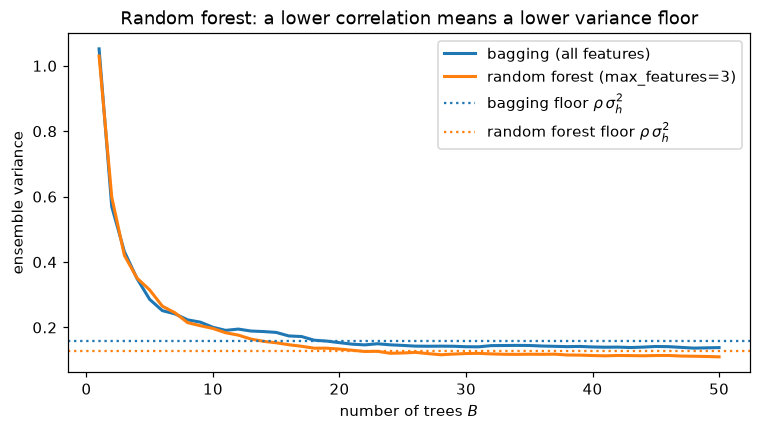

In [13]:
Bs = np.arange(1, M_RF + 1)
plt.figure(figsize=(8, 4))
plt.plot(Bs, [ensemble_stats_m(bag_preds_m, B)[1] for B in Bs], lw=2,
         label='bagging (all features)')
plt.plot(Bs, [ensemble_stats_m(rf_preds_m, B)[1] for B in Bs], lw=2,
         label=f'random forest (max_features={MAX_FEATURES})')
plt.axhline(rho_bag * sigma2_bag, color='tab:blue', ls=':',
            label=r'bagging floor $\rho\,\sigma_h^2$')
plt.axhline(rho_rf * sigma2_rf, color='tab:orange', ls=':',
            label=r'random forest floor $\rho\,\sigma_h^2$')
plt.xlabel('number of trees $B$'); plt.ylabel('ensemble variance')
plt.title('Random forest: a lower correlation means a lower variance floor')
plt.legend(); plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<p style="text-align: right;"><strong>آنچه باید مشاهده کنید:</strong></p>
<ul style="text-align: right;">
<li style="text-align: right;">همبستگی (correlation) اعضا کاهش می‌یابد (تقریباً $\rho \approx 0.18 \to 0.09$ در اینجا): زیرمجموعه‌های تصادفی ویژگی (feature) باعث ناهمخوانی درخت‌ها می‌شود.</li>
<li style="text-align: right;"><strong>واریانس به زیر کرانهٔ بگینگ (bagging) سقوط می‌کند</strong> — و کرانه‌های اندازه‌گیری‌شده نزدیک به $\rho\,\sigma_h^2$ پیش‌بینی ‌شده قرار می‌گیرند. ریاضیات بخش ۳ تزئینی نیست؛ واقعاً آزمایش را پیش‌بینی  می‌کند.</li>
<li style="text-align: right;"><strong>بایاس² کمی افزایش می‌یابد.</strong> بهای غیرهمبسته (uncorrelated)‌سازی: درختی که گاهی نمی‌تواند ویژگی ها (features)ی اطلاعاتی را ببیند انشعاب (split)‌های بدتری می‌زند. جنگل تصادفی (random forest) کمی بایاس را با مقدار زیادی واریانس معاوضه می‌کند — همان معاوضه، در جهت مخالف، که بوستینگ (boosting) انجام خواهد داد.</li>
<li style="text-align: right;">اثر خالص بر خطای مورد انتظار (expected error): تقریباً مساوی در اینجا، با برتری جزئی جنگل؛ روی داده‌های واقعی با ابعاد بالا (ویژگی ها (features)ی نویزی زیاد، مانند ۷ ویژگی (feature) ما) جنگل تصادفی (random forest) معمولاً به‌وضوح جلوتر است.</li>
</ul>

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="color: var(--jp-content-font-color1, #1e6bb8); text-align: right; font-family: 'Vazirmatn', sans-serif;">۴. بوستینگ (boosting) — مبارزه با بایاس</h2>

<p style="text-align: right;"><strong>ایده:</strong> یادگیرنده‌های ضعیف (weak learners) را <strong>متوالی</strong> آموزش  دهید، هر کدام روی آنچه گروه (ensemble) فعلی هنوز اشتباه می‌کند تمرکز کنند. با <strong>بوستینگ (boosting) گرادیانی (gradient boosting)</strong> (کمترین مربعات) و یک یادگیرندهٔ ضعیف (weak learner) $h$:</p>

<ol style="text-align: right;">
<li style="text-align: right;">با یک مدل ثابت شروع کنید: $F_0(x) = \bar{y}$.</li>
<li style="text-align: right;">در مرحلهٔ $m$، <strong>باقیمانده ها (residuals)</strong> را محاسبه کنید: $r_i = y_i - F_{m-1}(x_i)$ (برای هزینهٔ مربعاتی، باقیمانده (residual) <em>همان</em> گرادیان منفی است).</li>
<li style="text-align: right;">یک درخت کوچک $h_m$ را روی باقیمانده ها (residuals) برازش (fitting) دهید.</li>
<li style="text-align: right;">به‌روزرسانی: $F_m(x) = F_{m-1}(x) + \eta \, h_m(x)$، که $\eta \in (0, 1]$ <strong>نرخ یادگیری (learning rate)</strong> است.</li>
</ol>

<p style="text-align: right;">هر مرحله خطای باقی‌مانده را ترمیم می‌کند، پس گروه (ensemble) پیشرونده (progressive ensemble) قوی تر می‌شود — حتی از استمپ تصمیم ها (decision stumps). این یعنی <strong>کاهش بایاس</strong>.</p>

<p style="text-align: right;">نرخ یادگیری (learning rate) $\eta$ (که <em>shrinkage</em> نامیده می‌شود) هر ترمیم را کوچک نگه می‌دارد: گروه (ensemble) در گام‌های محتاطانهٔ زیاد به $f$ نزدیک می‌شود، که واریانس مدل نهایی را نیز کنترل می‌کند.</p>

</div>

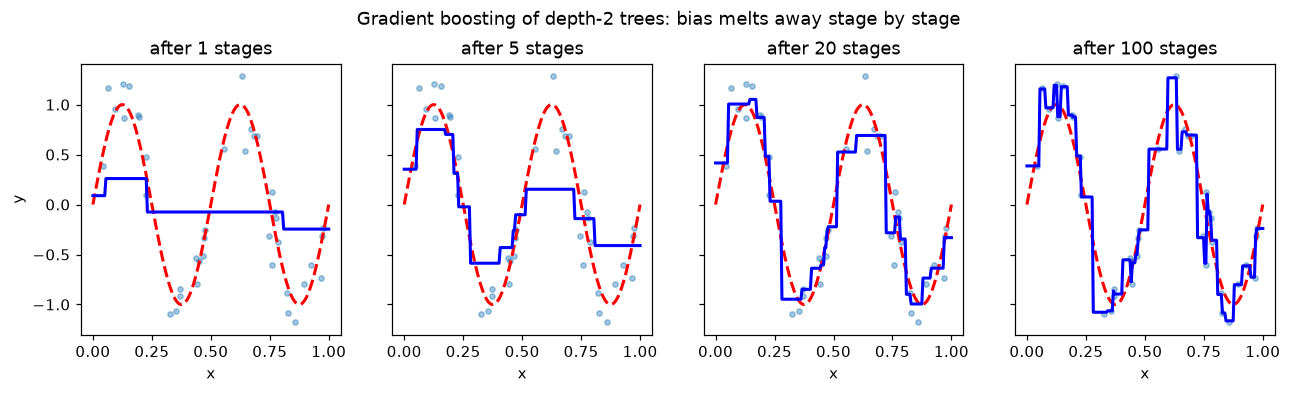

In [14]:
class SimpleGradientBoosting:
    """Gradient boosting from scratch (squared loss)."""
    def __init__(self, n_estimators=100, learning_rate=0.3, max_depth=2):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth

    def fit(self, X, y):
        """
        Fit gradient boosting with squared-error loss by sequentially fitting
        weak learners to the residuals of the current ensemble.

        Theory:
            Gradient Boosting reduces bias by training weak learners sequentially.
            Each new learner focuses on what the current ensemble still gets wrong.

            Algorithm (for squared loss):
                1. Initialize: F_0(x) = mean(y)  (a constant prediction)
                2. For m = 1 to n_estimators:
                   a. Compute residuals: r_i = y_i - F_{m-1}(x_i)
                      For squared loss, the residual is the negative gradient of the
                      loss function, hence the name 'gradient' boosting.
                   b. Fit a small decision tree h_m to the residuals r
                   c. Update: F_m(x) = F_{m-1}(x) + learning_rate * h_m(x)
                      The learning_rate (eta, also called shrinkage) controls how much
                      each step contributes. Smaller eta = more conservative = less
                      variance but needs more estimators.

            Unlike bagging (which averages independent models), boosting builds
            models ADDITIVELY. Each step reduces bias, making the ensemble much
            more expressive than any individual weak learner.

        Parameters:
            X : np.ndarray of shape (n_samples, n_features) - training features
            y : np.ndarray of shape (n_samples,) - training targets

        Returns:
            self : the fitted SimpleGradientBoosting instance

        Side effects:
            Must set self.f0 = float (initial constant prediction = mean of y)
            Must set self.trees = list of n_estimators fitted DecisionTreeRegressor objects
        """
        # TODO: implement gradient boosting fit
        raise NotImplementedError

    def predict(self, X, n_stages=None):
        """
        Predict by summing the initial constant and all (or first n_stages) tree contributions.

        Theory:
            The final prediction is:
                F(x) = f0 + learning_rate * sum_{m=1}^{M} h_m(x)
            where f0 = mean(y_train) and h_m are the sequentially fitted trees.
            Using n_stages < len(self.trees) lets you see how the ensemble
            improves as more stages are added.

        Parameters:
            X : np.ndarray of shape (n_samples, n_features) - features to predict on
            n_stages : int or None - number of boosting stages to use (None = all)

        Returns:
            np.ndarray of shape (n_samples,) - predictions
        """
        # TODO: implement gradient boosting predict
        raise NotImplementedError

# watch the ensemble learn the sine wave step by step
gb = SimpleGradientBoosting(n_estimators=100, learning_rate=0.3, max_depth=2).fit(X_demo, y_demo)
fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), sharey=True)
for ax, m in zip(axes, [1, 5, 20, 100]):
    ax.scatter(X_demo, y_demo, s=12, alpha=0.4)
    ax.plot(x_grid, f(x_grid), 'r--', lw=2)
    ax.plot(x_grid, gb.predict(x_grid, n_stages=m), 'b-', lw=2)
    ax.set_title(f'after {m} stages'); ax.set_xlabel('x')
axes[0].set_ylabel('y')
plt.suptitle('Gradient boosting of depth-2 trees: bias melts away stage by stage', y=1.03)
plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="color: var(--jp-content-font-color1, #1e6bb8); text-align: right; font-family: 'Vazirmatn', sans-serif;">۴.۱ آدابوست (AdaBoost) — بوستینگ (boosting) برای دسته‌بندی (classification)</h3>

<p style="text-align: right;">بوستینگ (boosting) گرادیانی (gradient boosting) با برازش (fitting) <strong>باقیمانده ها (residuals)</strong> بایاس را کاهش می‌دهد. <strong>آدابوست (AdaBoost)</strong>  بایاس را در <em>دسته‌بندی (classification)</em> با <strong>بازوزن‌دهی (re-weighting) نقاط آموزش  (re-weighting training points)</strong> کاهش می‌دهد:</p>

<ol style="text-align: right;">
<li style="text-align: right;">با وزن‌های مساوی شروع کنید: $w_i = 1/n$.</li>
<li style="text-align: right;">یک استمپ تصمیم (decision stump) $h_t$ را روی داده‌های <strong>وزن‌دار</strong> $w$ آموزش  دهید.</li>
<li style="text-align: right;">خطای وزن‌دار $\varepsilon_t = \sum_i w_i\,\mathbf{1}[h_t(x_i) \neq y_i]$، و اهمیت مدل $\alpha_t = \frac{1}{2}\ln\frac{1-\varepsilon_t}{\varepsilon_t}$ — یک استمپ تصمیم (decision stump)ٔ دقیق $\alpha$ بزرگی می‌گیرد (سهم بزرگی در رأی نهایی).</li>
<li style="text-align: right;"><strong>بازوزن‌دهی (re-weighting) اشتباهات</strong>: $w_i \leftarrow w_i\, e^{-\alpha_t\, y_i\, h_t(x_i)}$ (نقاط درست‌دسته‌بندی (classification)‌شده (correctly classified points) با $e^{-\alpha_t}$ کوچک می‌شوند، نقاط اشتباه (misclassified points) با $e^{+\alpha_t}$ بزرگ می‌شوند)، سپس وزن‌ها را نرمال کنید تا مجموعشان ۱ شود.</li>
<li style="text-align: right;">پیش‌بینی  نهایی: $H(x) = \operatorname{sign}\!\left(\sum_t \alpha_t\, h_t(x)\right)$ — یک <strong>رأی وزن‌دار (weighted vote)</strong> از همهٔ استمپ تصمیم ها (decision stumps).</li>
</ol>

<p style="text-align: right;">هر دور، استمپ تصمیم (decision stump)ٔ جدید مجبور است دقیقاً روی نقاطی تمرکز کند که گروه (ensemble) فعلی هنوز اشتباه دسته‌بندی (misclassified) می‌کند — همان مکانیزم کاهش بایاس مانند بوستینگ (boosting) گرادیانی (gradient boosting)، با حسابداری متفاوت.</p>

<p style="text-align: right;">دو تفاوت ارزش یادآوری:</p>
<ul style="text-align: right;">
<li style="text-align: right;">آدابوست (AdaBoost) از <strong>بازنمونه‌گیری (resampling) بوت‌استرپ استفاده نمی‌کند</strong> (این ترفند بگینگ (bagging) است) — هر استمپ تصمیم (decision stump) <em>همهٔ</em> داده‌ها را می‌بیند، فقط با وزن‌های متفاوت.</li>
<li style="text-align: right;">$\alpha_t$ آدابوست (AdaBoost) از خطاها <strong>تطبیقی</strong> انتخاب می‌شوند: گروه (ensemble) به‌طور خودکار تصمیم می‌گیرد چقدر به هر عضو اعتماد کند.</li>
</ul>

</div>

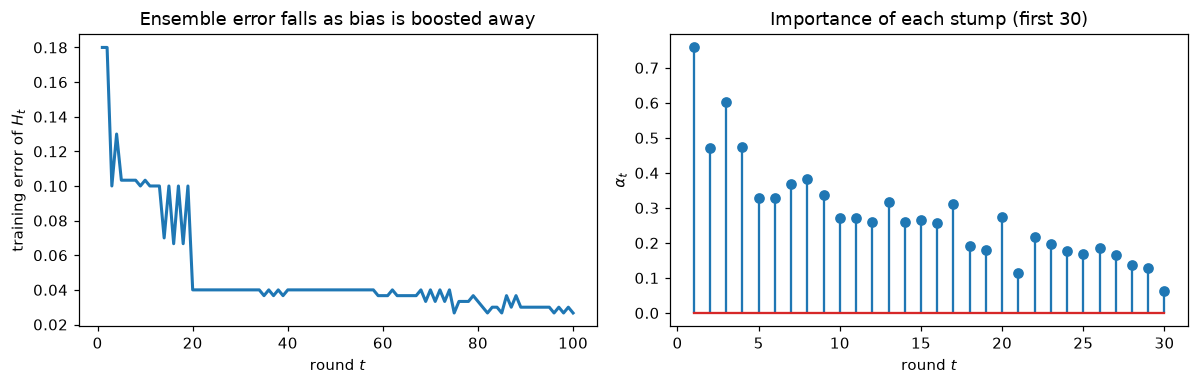

In [15]:
from sklearn.datasets import make_moons


class SimpleAdaBoost:
    """AdaBoost from scratch (binary classification, labels in {-1, +1})."""
    def __init__(self, n_estimators=100):
        self.n_estimators = n_estimators

    def fit(self, X, y):
        """
        Fit AdaBoost by sequentially training weighted decision stumps and
        re-weighting misclassified points.

        Theory:
            AdaBoost (Adaptive Boosting) reduces bias for classification by
            training weak learners (decision stumps) sequentially, where each
            new stump focuses more on previously misclassified points.

            Algorithm (binary classification, labels in {-1, +1}):
                1. Initialize equal weights: w_i = 1/n for all i
                2. For t = 1 to n_estimators:
                   a. Train a decision stump h_t on (X, y) with sample_weight=w
                   b. Compute weighted error:
                      epsilon_t = sum_{i: h_t(x_i) != y_i} w_i
                   c. Compute stump importance:
                      alpha_t = 0.5 * ln((1 - epsilon_t) / epsilon_t)
                      A more accurate stump gets a larger alpha (more voting power).
                   d. Update weights:
                      w_i <- w_i * exp(-alpha_t * y_i * h_t(x_i))
                      Correctly classified points: weight shrinks by exp(-alpha_t)
                      Misclassified points: weight grows by exp(+alpha_t)
                   e. Normalize weights so they sum to 1

            Final prediction: H(x) = sign(sum_t alpha_t * h_t(x))
            This is a weighted majority vote of all stumps.

            Key differences from bagging:
              - No bootstrap resampling (each stump sees ALL data, just with different weights)
              - alpha_t is chosen adaptively from the error (not fixed)

        Parameters:
            X : np.ndarray of shape (n_samples, n_features) - training features
            y : np.ndarray of shape (n_samples,) - training labels in {-1, +1}

        Returns:
            self : the fitted SimpleAdaBoost instance

        Side effects:
            Must set self.trees = list of n_estimators fitted DecisionTreeClassifier(max_depth=1)
            Must set self.alphas = list of n_estimators float importance values
            Must set self.weight_history = list of (n_estimators+1) weight arrays
                (weight_history[0] = initial weights, weight_history[t] = weights after round t)
        """
        # TODO: implement AdaBoost fit
        raise NotImplementedError

    def decision(self, X, n_stages=None):
        """
        Compute the weighted vote score: sum_t alpha_t * h_t(x).
        The sign of this score gives the final prediction.

        Parameters:
            X : np.ndarray of shape (n_samples, n_features) - features
            n_stages : int or None - number of stages to use (None = all)

        Returns:
            np.ndarray of shape (n_samples,) - weighted vote scores (real-valued)
        """
        # TODO: implement AdaBoost decision function
        raise NotImplementedError

    def predict(self, X, n_stages=None):
        """
        Predict class labels by taking the sign of the decision function.

        Parameters:
            X : np.ndarray of shape (n_samples, n_features) - features
            n_stages : int or None - number of stages to use (None = all)

        Returns:
            np.ndarray of shape (n_samples,) - predicted labels in {-1, +1}
        """
        # TODO: implement AdaBoost predict
        raise NotImplementedError

# --- train on the two-moons dataset (labels -> {-1, +1}) ---
Xc, yc = make_moons(n_samples=300, noise=0.25, random_state=7)
yc_pm = np.where(yc == 0, -1, 1)

ada = SimpleAdaBoost(n_estimators=100).fit(Xc, yc_pm)

# training error of the ensemble after r rounds, and the stump importances alpha_t
rounds = np.arange(1, ada.n_estimators + 1)
train_err = [np.mean(ada.predict(Xc, n_stages=r) != yc_pm) for r in rounds]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.plot(rounds, train_err, lw=2)
ax1.set_xlabel('round $t$'); ax1.set_ylabel('training error of $H_t$')
ax1.set_title('Ensemble error falls as bias is boosted away')
ax2.stem(rounds[:30], ada.alphas[:30])
ax2.set_xlabel('round $t$'); ax2.set_ylabel(r'$\alpha_t$')
ax2.set_title('Importance of each stump (first 30)')
plt.tight_layout(); plt.show()

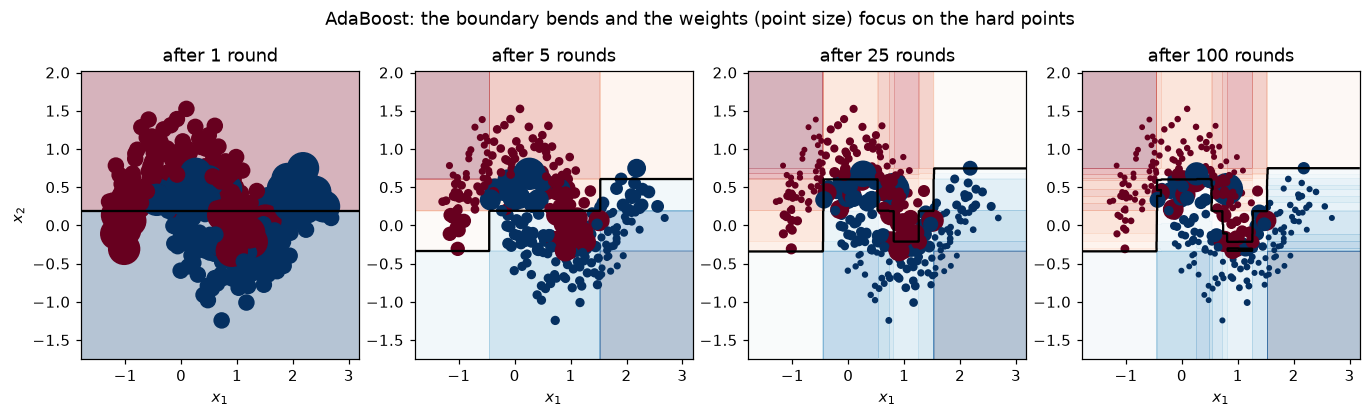

In [16]:
# watch the ensemble build its decision boundary + the weights focus on hard points
x_min, x_max = Xc[:, 0].min() - 0.5, Xc[:, 0].max() + 0.5
y_min, y_max = Xc[:, 1].min() - 0.5, Xc[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, t in zip(axes, [1, 5, 25, 100]):
    Z = ada.decision(grid, n_stages=t).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, cmap='RdBu', alpha=0.3)
    ax.contour(xx, yy, Z, levels=[0], colors='k', linewidths=1.5)   # decision boundary
    w = ada.weight_history[t]                                       # weights after round t
    ax.scatter(Xc[:, 0], Xc[:, 1], c=yc_pm, cmap='RdBu', s=8 + 400 * w / w.max())
    ax.set_title(f'after {t} round{"s" if t > 1 else ""}')
    ax.set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
plt.suptitle('AdaBoost: the boundary bends and the weights (point size) focus on the hard points', y=1.04)
plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<p style="text-align: right;"><strong>آنچه باید مشاهده کنید:</strong></p>
<ul style="text-align: right;">
<li style="text-align: right;">پس از <strong>۱ دور</strong> مرز تصمیم (decision boundary) یک استمپ تصمیم (decision stump)ٔ تکی است — یک برش خطی، با بایاس شدید (ماه‌ها جداپذیر خطی نیستند).</li>
<li style="text-align: right;">با دورهای بیشتر مرز <strong>خم می‌شود</strong>، زیرا استمپ تصمیم ها (decision stumps)ی بعدی (متمرکز بر نقاط سختِ با وزن بالا) رأی به اصلاح استمپ تصمیم ها (decision stumps)ی قبلی می‌دهند — گروه (ensemble) بسیار پربیانی‌تر از هر استمپ تصمیم (decision stump)ٔ تکی است. <strong>این یعنی کاهش بایاس.</strong></li>
<li style="text-align: right;">اندازهٔ نقاط وزن‌ها را نشان می‌دهد: روی نقاط نزدیک مرز که استمپ تصمیم ها (decision stumps)ی قبلی مدام اشتباه دسته‌بندی (misclassified) می‌کردند متمرکز می‌شوند.</li>
<li style="text-align: right;">در نمودار چپ، خطای آموزش  مدام کاهش می‌یابد و سپس تثبیت می‌شود — بوستینگ (boosting) مانند بگینگ (bagging) از بهبود بازنمی‌ایستد (خطای بگینگ (bagging) وقتی واریانس از بین رفت اشباع می‌شود).</li>
</ul>

<p style="text-align: right;"><em>احتیاط:</em> روی داده‌های نویزی، این بهبود نامحدود در نهایت به <strong>بیش‌برازش (overfitting)</strong> تبدیل می‌شود — خطای آموزش  کاهش می‌یابد در حالی که خطای آزمون بالا می‌رود. پیاده‌سازی‌های واقعی از نرخ یادگیری (learning rate)، زیرنمونه‌گیری (subsampling) یا توقف زودهنگام (early stopping) برای کنترل این موضوع استفاده می‌کنند.</p>

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="color: var(--jp-content-font-color1, #1e6bb8); text-align: right; font-family: 'Vazirmatn', sans-serif;">۴.۲ اندازه‌گیری: بایاس و واریانس گروه (ensemble) بوستینگ (boosting) (boosting ensemble)</h3>

</div>

In [17]:
def gb_fit_predict(n_stages=100, lr=0.3, depth=2, n_train=40):
    def run(trial):
        rng = np.random.default_rng(trial)
        X, y = make_dataset(n_train, rng=rng)
        gb = SimpleGradientBoosting(n_estimators=n_stages, learning_rate=lr, max_depth=depth).fit(X, y)
        return gb.predict(x_grid)
    return run

b2_stump, v_stump, _ = measure_bias_variance(tree_fit_predict(1), n_trials=N_TRIALS)
b2_bag, v_bag = bagging_stats(50)
b2_gb, v_gb, _ = measure_bias_variance(gb_fit_predict(), n_trials=N_TRIALS)

summary = pd.DataFrame([
    {'model': 'single stump (depth 1)',        'bias^2': b2_stump, 'variance': v_stump},
    {'model': f'bagging, 50 x depth-{BASE_DEPTH}', 'bias^2': b2_bag,  'variance': v_bag},
    {'model': 'boosting, 100 x depth-2 trees', 'bias^2': b2_gb,   'variance': v_gb},
]).set_index('model').round(3)
summary['expected error'] = (summary['bias^2'] + summary['variance'] + NOISE_VAR).round(3)
summary

,bias^2,variance,expected error
model,,,
single stump (depth 1),0.303,0.086,0.479
"bagging, 50 x depth-3",0.035,0.048,0.173
"boosting, 100 x depth-2 trees",0.002,0.106,0.198


<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<p style="text-align: right;"><strong>آنچه باید مشاهده کنید:</strong></p>
<ul style="text-align: right;">
<li style="text-align: right;"><strong>استمپ تصمیم (decision stump)</strong> بایاس² بزرگ و واریانس کوچک دارد.</li>
<li style="text-align: right;"><strong>بگینگ (bagging)</strong> (درخت‌های عمق ۳) بایاس را مشابه درخت عمق ۳ تکی نگه می‌دارد اما واریانس را به‌شدت کاهش می‌دهد.</li>
<li style="text-align: right;"><strong>بوستینگ (boosting)</strong> (درخت‌های عمق ۲) <strong>بایاس</strong> را کاهش می‌دهد — برازش (fitting) متوالی باقیمانده ها (residuals) تابعی بسیار پربیانی‌تر می‌سازد — در حالی که واریانس را به‌لطف گام‌های کوچک $\eta$ متعادل نگه می‌دارد.</li>
</ul>

<p style="text-align: right;">دقت: بوستینگ (boosting) <em>عاری از واریانس</em> نیست. اگر اجازه دهید خیلی طولانی اجرا شود یا از $\eta$ بزرگ استفاده کنید، شروع به برازش (fitting) نویز می‌کند — بایاس کاهش می‌یابد در حالی که واریانس رشد می‌کند و در نهایت خطا برمی‌گردد. این نسخهٔ بوستینگ (boosting) از موازنهٔ بایاس–واریانس (bias-variance tradeoff) است.</p>

</div>

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="color: var(--jp-content-font-color1, #1e6bb8); text-align: right; font-family: 'Vazirmatn', sans-serif;">۵. مقایسهٔ کنار به کنار</h2>

<p style="text-align: right;">همان سه مدل، در یک تصویر: بایاس²، واریانس، نویز و مجموعشان (خطای مورد انتظار (expected error)).</p>

</div>

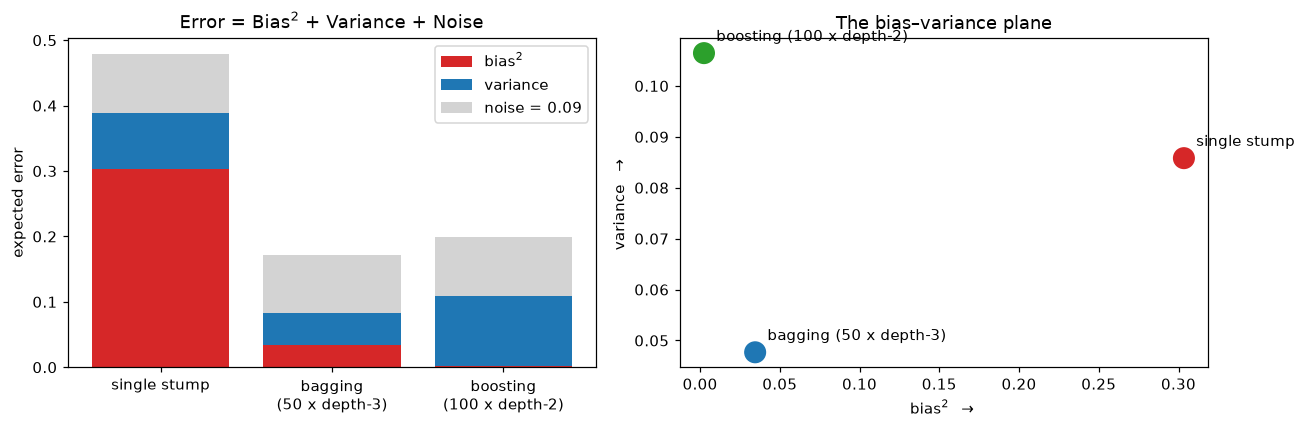

In [18]:
names = ['single stump', f'bagging\n(50 x depth-{BASE_DEPTH})', 'boosting\n(100 x depth-2)']
bias_vals = [b2_stump, b2_bag, b2_gb]
var_vals  = [v_stump, v_bag, v_gb]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
xpos = np.arange(3)
ax1.bar(xpos, bias_vals, color='tab:red', label='bias$^2$')
ax1.bar(xpos, var_vals, bottom=bias_vals, color='tab:blue', label='variance')
ax1.bar(xpos, [NOISE_VAR]*3, bottom=np.array(bias_vals)+np.array(var_vals),
        color='lightgray', label=f'noise = {NOISE_VAR:.2f}')
ax1.set_xticks(xpos); ax1.set_xticklabels(names); ax1.set_ylabel('expected error')
ax1.set_title('Error = Bias$^2$ + Variance + Noise'); ax1.legend()

ax2.scatter(bias_vals, var_vals, s=180, c=['tab:red', 'tab:blue', 'tab:green'], zorder=3)
for name, bx, vx in zip(names, bias_vals, var_vals):
    ax2.annotate(name.replace('\n', ' '), (bx, vx), xytext=(8, 8), textcoords='offset points')
ax2.set_xlabel('bias$^2$  $\\rightarrow$'); ax2.set_ylabel('variance  $\\rightarrow$')
ax2.set_title('The bias–variance plane')
plt.tight_layout(); plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h3 style="color: var(--jp-content-font-color1, #1e6bb8); text-align: right; font-family: 'Vazirmatn', sans-serif;">جایزه: همان داستان روی یک مسئلهٔ دسته‌بندی (classification) واقعی</h3>

<p style="text-align: right;">دو ماه: یک <strong>استمپ تصمیم (decision stump)</strong> کم‌برازش (underfitting) دارد (بایاس بالا)، یک <strong>جنگل تصادفی (random forest)</strong> (بگینگ (bagging) + تصادفی‌سازی ویژگی (feature)) و <strong>آدابوست (AdaBoost)</strong> (بوستینگ (boosting) با داده‌های بازوزن‌دهی (re-weighting)‌شده) هر کدام به شیوهٔ متفاوتی مسئله را حل می‌کنند.</p>

</div>

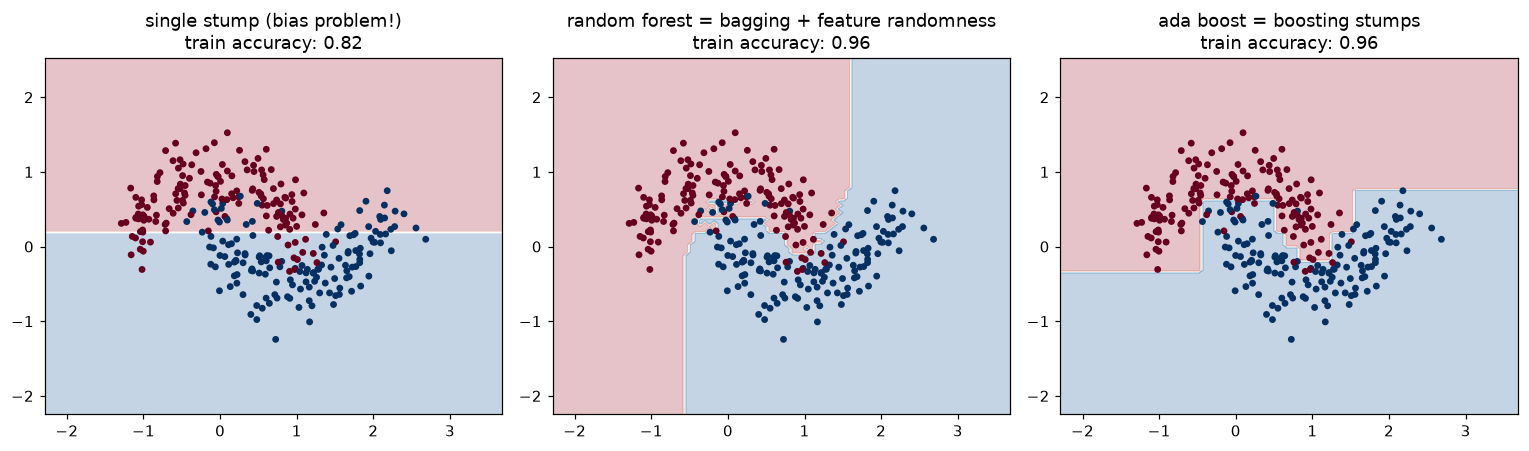

In [19]:
from sklearn.datasets import make_moons
from sklearn.inspection import DecisionBoundaryDisplay

Xc, yc = make_moons(n_samples=300, noise=0.25, random_state=7)
models = {
    'single stump (bias problem!)': DecisionTreeClassifier(max_depth=1),
    'random forest = bagging + feature randomness': RandomForestClassifier(n_estimators=200, max_depth=5, random_state=0),
    'ada boost = boosting stumps': AdaBoostClassifier(
        DecisionTreeClassifier(max_depth=1), n_estimators=200, learning_rate=0.5, random_state=0),
}
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (name, model) in zip(axes, models.items()):
    model.fit(Xc, yc)
    DecisionBoundaryDisplay.from_estimator(model, Xc, ax=ax, cmap='RdBu', alpha=0.25, response_method='predict')
    ax.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap='RdBu', s=12)
    ax.set_title(f'{name}\ntrain accuracy: {model.score(Xc, yc):.2f}')
plt.tight_layout(); plt.show()

<div dir="rtl" lang="fa" style="font-family: 'Vazirmatn', sans-serif; line-height: 1.8; direction: rtl; text-align: right;">
<h2 style="color: var(--jp-content-font-color1, #1e6bb8); text-align: right; font-family: 'Vazirmatn', sans-serif;">خلاصه</h2>

<table style="text-align: right; width: 100%; border-collapse: collapse; font-family: 'Vazirmatn', sans-serif;">
<thead>
<tr style="text-align: right; border-bottom: 2px solid #ccc;">
<th style="text-align: right; padding: 6px;">مدل</th>
<th style="text-align: right; padding: 6px;">بایاس</th>
<th style="text-align: right; padding: 6px;">واریانس</th>
<th style="text-align: right; padding: 6px;">سازوکار</th>
</tr>
</thead>
<tbody>
<tr style="text-align: right;"><td style="padding: 6px;">یادگیرندهٔ ضعیف (weak learner) (استمپ تصمیم (decision stump))</td><td style="padding: 6px;"><strong>بالا</strong></td><td style="padding: 6px;">کم</td><td style="padding: 6px;">خیلی خشک، خطای سیستماتیک (systematic error) یکسان روی هر مجموعه‌داده </td></tr>
<tr style="text-align: right;"><td style="padding: 6px;">درخت عمیق</td><td style="padding: 6px;">کم</td><td style="padding: 6px;"><strong>غالب</strong></td><td style="padding: 6px;">خیلی انعطاف‌پذیر، نویز هر مجموعه‌داده  را دنبال می‌کند</td></tr>
<tr style="text-align: right;"><td style="padding: 6px;"><strong>بگینگ (bagging)</strong></td><td style="padding: 6px;">~بدون تغییر</td><td style="padding: 6px;"><strong>↓ ↓</strong></td><td style="padding: 6px;">میانگین $B$ مدل آموزش ‌دیده با بوت‌استرپ</td></tr>
<tr style="text-align: right;"><td style="padding: 6px;"><strong>جنگل تصادفی (random forest)</strong></td><td style="padding: 6px;">کمی ↑</td><td style="padding: 6px;"><strong>↓ ↓ ↓</strong></td><td style="padding: 6px;">بگینگ (bagging) + زیرمجموعهٔ تصادفی (random subset) ویژگی (feature) در هر انشعاب (split)؛ درخت‌های غیرهمبسته (uncorrelated) → $\rho$ کوچک‌تر → کرانهٔ واریانس (variance floor) پایین‌تر</td></tr>
<tr style="text-align: right;"><td style="padding: 6px;"><strong>بوستینگ (boosting)</strong></td><td style="padding: 6px;"><strong>↓ ↓</strong></td><td style="padding: 6px;">متوسط</td><td style="padding: 6px;">یادگیرنده‌های متوالی باقیمانده ها (residuals)ی مرحلهٔ قبل را برازش (fitting) می‌دهند</td></tr>
</tbody>
</table>

<p style="text-align: right;"><strong>پیام‌های کلیدی در یک جمله:</strong></p>
<ul style="text-align: right;">
<li style="text-align: right;"><em>بگینگ (bagging)</em> مدل‌های پرواریانس زیاد را به یک مدل پایدار تبدیل می‌کند — آن را روی یادگیرنده‌های پایهٔ انعطاف‌پذیر به کار ببرید.</li>
<li style="text-align: right;"><em>جنگل تصادفی (random forest)</em> همان بگینگ (bagging) به‌علاوهٔ غیرهمبسته (uncorrelated)‌سازی است: زیرمجموعه‌های تصادفی ویژگی (feature) کرانهٔ واریانس (variance floor) $\rho\,\sigma_h^2$ را پایین می‌آورند.</li>
<li style="text-align: right;"><em>بوستینگ (boosting)</em> مدل‌های پربایاس زیاد را به یک مدل پربیانی تبدیل می‌کند — آن را روی یادگیرنده‌های پایهٔ ضعیف به کار ببرید.</li>
<li style="text-align: right;">هیچ‌کدام نمی‌توانند نویز تحویل‌ناپذیر $\sigma^2$ را حذف کنند.</li>
</ul>

</div>